# Customer Personality Analysis - Unsupervised Learning

Dataset source: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data

This project applies unsupervised learning techniques to identify natural customer segments and detect atypical customer behavior for targeted marketing strategy.

I've used the following unsupervised learning methods:


*  Data cleaning and preprocessing
*  PCA : to analyze feature redundancy and reduce dimensionality
*  UMAP & t-SNE : to visualize customer structure in 2D space
*  K-Means clustering : to segment customers into interpretable groups
*  Isolation Forest : to detect behavioral outliers






## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
#!pip install umap-learn   <- we only need to run this once
import umap



## Loading & Preprocessing

In [2]:
#please upload the dataset before running (dataset file gets deleted after runtime)
data = pd.read_csv('/content/sample_data/marketing_campaign.csv', sep='\t')
print(data.shape)
data.head()


(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Preprocessing

During preprocessing, I removed non-informative columns (ID and registration date), selected only numeric features, imputed missing values using median imputation to preserve all records, and standardized the data using z-score scaling to ensure all variables contributed equally to downstream PCA and clustering.

In [ ]:
from sklearn.impute import SimpleImputer
data = data.drop(columns=['ID', 'Dt_Customer'])
df_numeric = data.select_dtypes(include=[np.number])
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric),
    columns=df_numeric.columns
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)


print(f'Shape after preprocessing: {df_imputed.shape}')


Shape after preprocessing: (2240, 25)


## Dimensionality Reduction

### PCA

We run PCA in three ways:

*   2 components for 2D visualisation
*   n_components=0.95 to find the minimum components that retain 95% variance
*   Full PCA to plot the cumulative explained variance (scree plot)

In [ ]:
# applied PCA with two components to reduce the dataset to 2D for visualization purposes
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print('Explained variance ratio (2 components):', pca_2.explained_variance_ratio_.round(3))
print('Total variance explained:', pca_2.explained_variance_ratio_.sum().round(3))


Explained variance ratio (2 components): [0.283 0.088]
Total variance explained: 0.371


In [ ]:
# Minimum components to retain 95% of variance
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print('Components needed for 95% variance:', pca_95.n_components_)
# Result is 19 which implies that the dataset has moderate redundancy


Components needed for 95% variance: 19


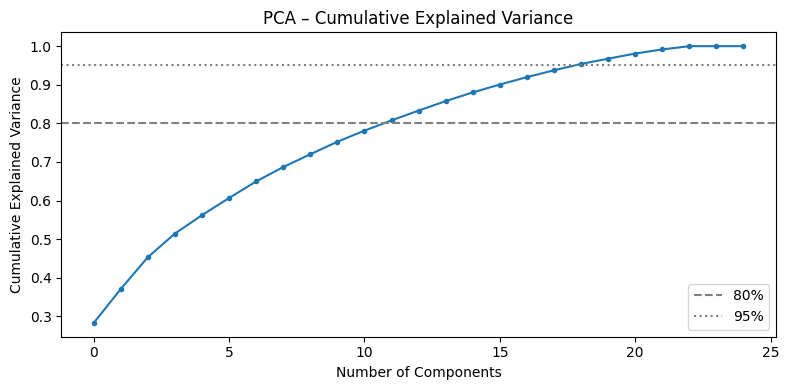

Components for 80%: 12 | for 95%: 19


In [ ]:
# Scree plot
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar, marker='o', markersize=3)
plt.axhline(0.80, ls='--', color='gray', label='80%')
plt.axhline(0.95, ls=':', color='gray', label='95%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_80 = int((cumvar >= 0.80).argmax()) + 1
print(f'Components for 80%: {n_80} | for 95%: {pca_95.n_components_}')


**Interpretation**: The PCA plot shows that the first few components capture a large portion of the dataset's information, as the curve rises steeply at the beginning. After around 10 to 12 components, the curve starts to flatten, meaning each additional component contributes less new information. About 19 components are needed to retain 95% of the total variance, which suggests there is some correlation between features, but the dataset still contains a meaningful amount of independent information.

### UMAP

UMAP is a non-linear technique that preserves both local and global structure. Two key parameters control its behavior:
*  n_neighbors: Determines the balance between local and global structure. Higher values capture more global patterns, while lower values focus on local neighborhood relationships.
*  min_dist: Controls how tightly points are clustered in the low-dimensional space. Lower values result in more compact clusters, while higher values produce more spread-out embeddings.



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


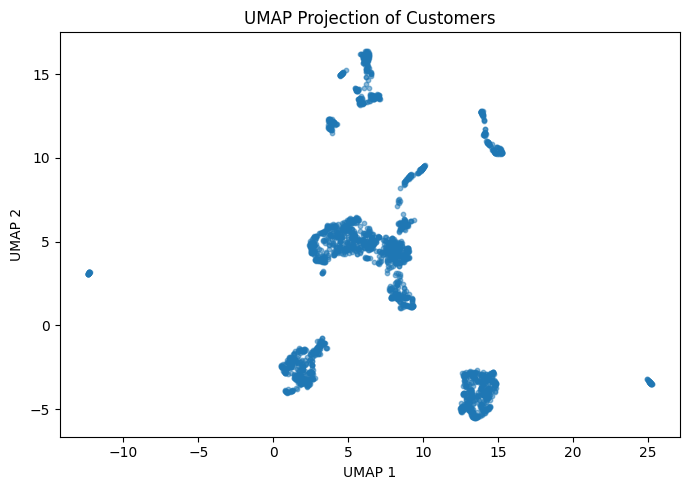

In [ ]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=10)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Projection of Customers')
plt.tight_layout()
plt.show()


### t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique primarily used for high-quality data visualization. It emphasizes preserving local neighborhood structure, ensuring that similar observations remain close together in the lower-dimensional embedding.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


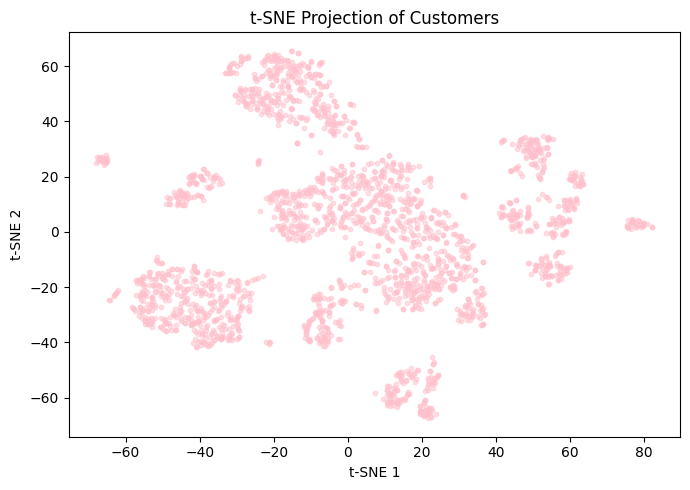

In [ ]:
# Reduce dimensionality with PCA before applying t-SNE (improves stability and speed)
pca_pre = PCA(n_components=20, random_state=42)
X_pca_pre = pca_pre.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,      # Controls neighborhood size (typically 15–50)
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca_pre)

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=10, color='pink')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Projection of Customers')
plt.tight_layout()
plt.show()


### UMAP vs t-SNE – Comparison

Comparing both projections by Response (campaign acceptance) to visually check whether the natural structure aligns with a meaningful business variable — without using it as a label

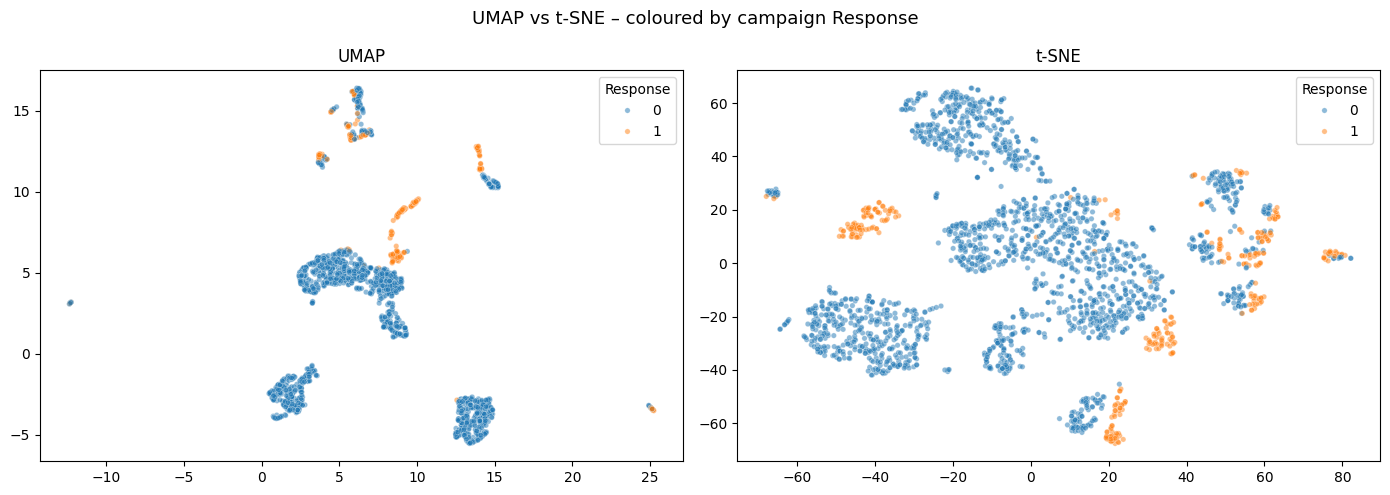

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (coords, title) in zip(axes, [(X_umap, 'UMAP'), (X_tsne, 't-SNE')]):
    sns.scatterplot(
        x=coords[:, 0], y=coords[:, 1],
        hue=data['Response'].astype('category'),
        ax=ax, alpha=0.5, s=15
    )
    ax.set_title(title)

plt.suptitle('UMAP vs t-SNE – coloured by campaign Response', fontsize=13)
plt.tight_layout()
plt.show()

# Note: used 'Response' here for visual interpretation only


**Interpretation**: The UMAP and t-SNE projections both reveal clear groupings within the customer base, suggesting that meaningful structure exists in the data. When coloured by campaign response, customers who accepted the campaign (Response = 1) tend to cluster in specific regions rather than being evenly distributed across all groups.
UMAP shows more globally coherent clusters, with clearer separation between major segments. t-SNE, on the other hand, produces tighter local groupings but slightly distorts global distances between clusters. Despite these differences, both methods consistently indicate that campaign responders are concentrated in particular areas of the embedding space.
This suggests that campaign acceptance is not random, but associated with underlying behavioural or demographic patterns captured by the unsupervised structure.

## Clustering

### K-Means – Choosing k

I've clustered on the **UMAP embedding** — it already captures the structure compactly in 2D and produces cleaner, more visually consistent clusters. The elbow method is used to pick the value of k.

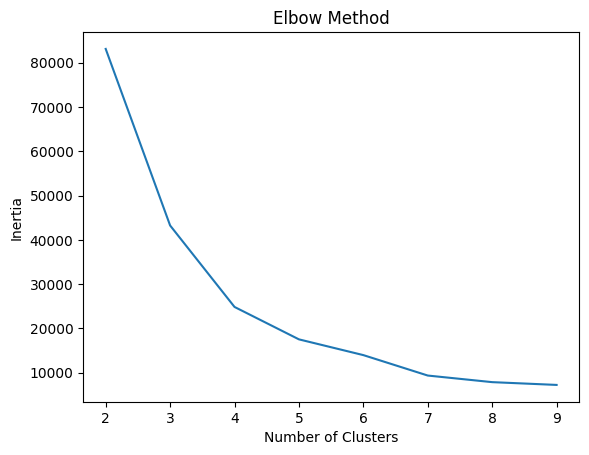

In [ ]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()



This “elbow” around k = 5 suggests that five clusters provide a good balance between model complexity and explanatory power. Beyond this point, increasing the number of clusters yields diminishing returns and may lead to over-segmentation without substantial improvement in cluster cohesion.

In [ ]:
K = 5

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_umap)
data['Cluster'] = clusters

print(f'Silhouette Score (k={K}):', silhouette_score(X_umap, clusters).round(3))
print('Cluster sizes:')
print(pd.Series(clusters).value_counts().sort_index())


Silhouette Score (k=5): 0.671
Cluster sizes:
0    359
1    424
2    202
3    957
4    298
Name: count, dtype: int64


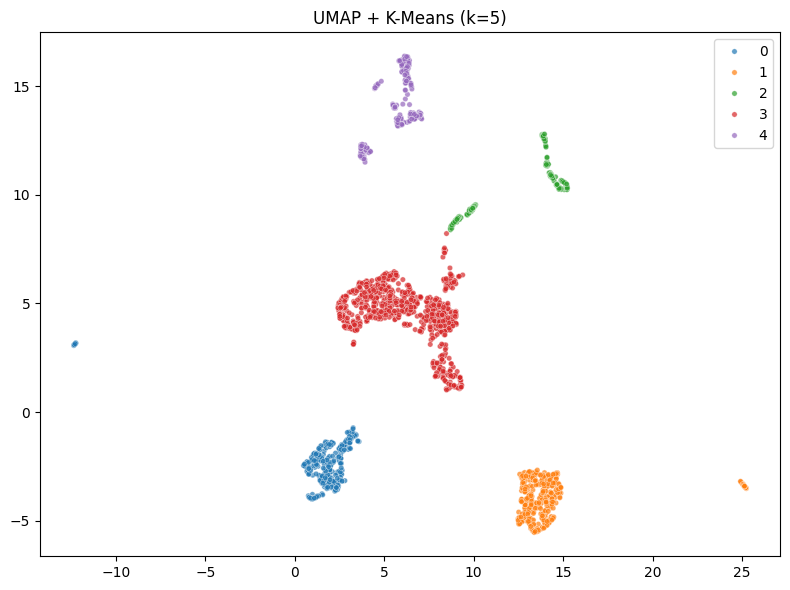

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=clusters, palette='tab10', s=15, alpha=0.7
)
plt.title(f'UMAP + K-Means (k={K})')
plt.tight_layout()
plt.show()


### Cluster Profiles

In [ ]:
profile_cols = ['Income', 'MntWines', 'MntMeatProducts', 'MntFishProducts',
                'Kidhome', 'Teenhome', 'NumStorePurchases', 'Recency', 'Response']

profile = data.groupby('Cluster')[profile_cols].mean().round(1)
print('Cluster profiles (mean values):')
print(profile)


Cluster profiles (mean values):
          Income  MntWines  MntMeatProducts  MntFishProducts  Kidhome  \
Cluster                                                                 
0        42996.8     100.7             43.5              9.3      1.1   
1        34028.0      99.7             45.1             11.8      1.0   
2        39431.2     193.7             70.9             15.3      0.7   
3        59622.8     360.4            223.8             54.1      0.0   
4        74236.7     732.7            371.5             70.0      0.1   

         Teenhome  NumStorePurchases  Recency  Response  
Cluster                                                  
0             1.0                3.9     51.8       0.0  
1             0.0                3.7     51.9       0.0  
2             0.5                4.0     36.7       0.7  
3             0.6                7.1     49.2       0.1  
4             0.4                8.1     50.1       0.4  


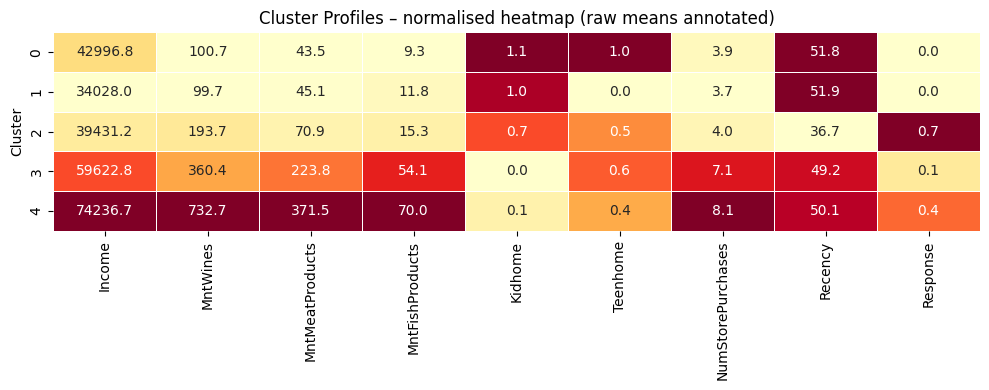

In [ ]:
# Normalised heatmap makes it easier to compare across clusters
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
plt.figure(figsize=(10, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar=False)
plt.title('Cluster Profiles – normalised heatmap (raw means annotated)')
plt.tight_layout()
plt.show()


The heatmap shows many differences between the five customer groups.


*   Cluster 0 : Low-Spend Families

This group has lower income, low overall spending, and a higher number of children. Campaign response is very low. These customers appear price-sensitive and less engaged with marketing efforts.
*   Cluster 1 : Budget-Conscious Households

Similar to Cluster 0 in spending and income, but slightly different in family composition. They purchase modestly and rarely respond to campaigns. Likely focused on essentials rather than discretionary products.
*   Cluster 2 : Mid-Income Regular Buyers

This group sits in the middle across most variables. Income and spending are moderate. Interesting to note that this group is highly responsive to campaigns which means that they can be a target demographic for marketing.
*   Cluster 3 : Engaged, Higher-Spending Customers

This segment shows higher income and stronger spending, especially in premium categories. Campaign responsiveness is almost not present. These customers are spenders but do not necessarily respond.
*   Cluster 4 : Premium High-Value Segment

This is the highest-income and highest-spending group by a clear margin. They spend heavily across categories and show strong purchasing activity. Response is not as high as cluster 2 but it is pretty good as in they can also serve as a target demographic especially because they definitely have the spending power.












## Anomaly Detection

### Isolation Forest

Isolation Forest isolates points using random splits. Anomalous points require fewer splits (they are easier to separate from the rest) and get shorter average path lengths. contamination=0.02 means we expect roughly 2% of customers to be anomalous.

In [ ]:
iso = IsolationForest(contamination=0.02, n_estimators=200, random_state=42)
anomalies = iso.fit_predict(X_scaled)

data['Anomaly'] = anomalies

print(data.groupby('Anomaly')['Response'].mean())

print(f"Outlier rate: {(anomalies == -1).mean():.2%}")


Anomaly
-1    0.844444
 1    0.134852
Name: Response, dtype: float64
Outlier rate: 2.01%


This is quite an interesting result because it shows that a whopping majority of outliers are actually highly responsive which could mean that this has the potential to be a very highly engaged VIP customer group within the existing clusters. Additionally, I'm aware that usually anamoly detection is performed before clustering in order to not skew the clusters but in this case it provided a group of high value customers that would have otherwise been removed completely which is not something we desire.

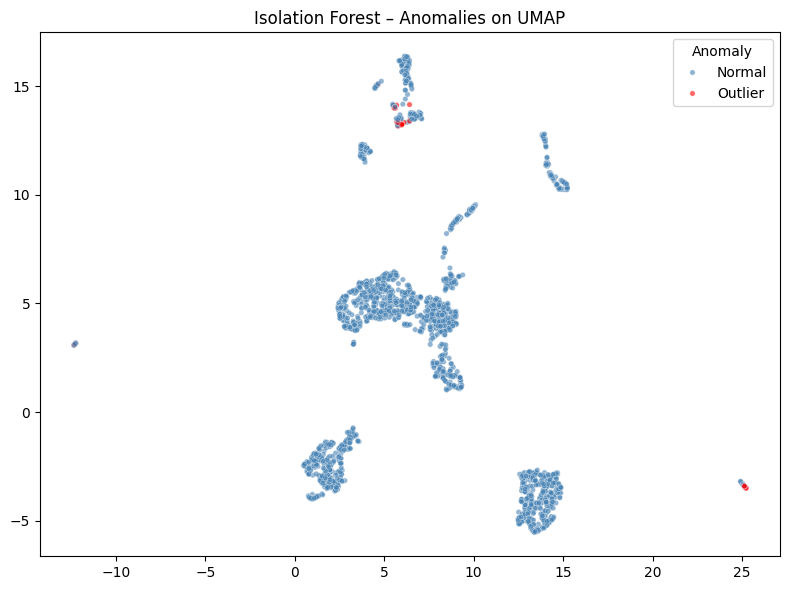

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=data['Anomaly'].map({1: 'Normal', -1: 'Outlier'}),
    palette={'Normal': 'steelblue', 'Outlier': 'red'},
    s=15, alpha=0.6
)
plt.title('Isolation Forest – Anomalies on UMAP')
plt.tight_layout()
plt.show()



In [ ]:
# Anomaly distribution across clusters
print('\nAnomaly distribution per cluster:')
print(pd.crosstab(data['Cluster'], data['Anomaly']))



Anomaly distribution per cluster:
Anomaly  -1    1
Cluster         
0         2  357
1        15  409
2         0  202
3         0  957
4        28  270


Clusters 1 and 3 contain the majority of the detected anomalies, suggesting that these segments include customers with more extreme behavioral patterns. Rather than representing poorly defined clusters, this may indicate that these groups capture high-variance or high-intensity customers.
Additionally, anomalous customers exhibit a significantly higher campaign response rate compared to the overall population, confirming that they behave distinctly from the majority. This suggests that the anomalies may represent highly engaged or high-value customers rather than random noise.

## **Conclusions**

## **Dimensionality Reduction**
PCA indicates that approximately 19 components are required to retain 95% of the variance, suggesting moderate feature redundancy while still preserving substantial independent information across variables.
Both UMAP and t-SNE reveal clear and consistent structure in the data, indicating the presence of natural customer groupings. UMAP is preferred for downstream clustering due to its computational efficiency, stability, and better preservation of global relationships between segments.

## **Clustering**
K-Means clustering applied to the UMAP embedding with k = 5 produces well-separated and interpretable customer segments.
The silhouette score (~0.67) confirms strong cluster separation and cohesion.
Cluster profiling demonstrates meaningful differences in income, spending behavior, household composition, and campaign responsiveness, allowing the segments to be translated into actionable marketing personas.

## **Anomaly Detection**
Isolation Forest identifies approximately 2% of customers as outliers. These anomalies are not randomly distributed but are concentrated primarily in specific clusters.
More importantly, anomalous customers exhibit a substantially higher campaign response rate than the overall population, suggesting that they represent highly engaged or atypical high-value customers rather than noise.

## **Business Takeaway**
The five identified segments provide a clear foundation for targeted marketing strategies, including differentiated approaches for premium, responsive, and price-sensitive customers.
Anomalous customers warrant separate strategic consideration, as their unusually high responsiveness and distinct behavior may represent either VIP opportunities or edge-case profiles requiring tailored engagement.